In [ ]:
# Kindly please install these dependencies
!pip install ucimlrepo
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install sklearn

In [ ]:
# Importing all the necessary packages into the notebook
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# Writing a custome KNN classifier class
class KNNClassifier:
    # Initialising the constructor
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    # Method to fit the training data
    def fit(self, X, y):
        """Stores the training data (KNN is a lazy learner)."""
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    # Method to predict the data
    def predict(self, X):
        """Predicts labels for the provided data points."""
        X = np.array(X)
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

    def _predict_single(self, x):
        # Calculate Euclidean distances between x and all points in X_train
        # Distance formula: sqrt(sum((x_i - y_i)^2))
        distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))

        # Get indices of the k smallest distances
        k_indices = np.argsort(distances)[:self.k]

        # Extract the labels of these k nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Return the most common class label (majority vote)
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

In [21]:
# fetch data
def get_data(id):
    dataset = fetch_ucirepo(id=id)
    X = dataset.data.features.values
    y = dataset.data.targets.values.ravel()
    return X, y

In [22]:
# Fetch Iris (id=53) and Wine (id=109)
datasets = {
    "Iris": get_data(53),
    "Wine": get_data(109)
}

# --- 2. Evaluation Logic ---
def run_comparison(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Classifiers to test
    models = {
        "Custom KNN (k=5)": KNNClassifier(k=5),
        "Sklearn KNN": KNeighborsClassifier(n_neighbors=5),
        "Decision Tree": DecisionTreeClassifier(random_state=42)
    }

    report = {}
    for name, model in models.items():
        # Training
        t0 = time.time()
        model.fit(X_train, y_train)
        t_train = time.time() - t0

        # Prediction
        t1 = time.time()
        preds = model.predict(X_test)
        t_pred = time.time() - t1

        report[name] = {
            "Accuracy": accuracy_score(y_test, preds),
            "Train Time": t_train,
            "Pred Time": t_pred,
            "Confusion Matrix": confusion_matrix(y_test, preds)
        }
    return report

# Execute experiments
final_results = {d_name: run_comparison(*d_data) for d_name, d_data in datasets.items()}

In [23]:
final_results

{'Iris': {'Custom KNN (k=5)': {'Accuracy': 1.0,
   'Train Time': 9.298324584960938e-06,
   'Pred Time': 0.002192974090576172,
   'Confusion Matrix': array([[19,  0,  0],
          [ 0, 13,  0],
          [ 0,  0, 13]])},
  'Sklearn KNN': {'Accuracy': 1.0,
   'Train Time': 0.001371145248413086,
   'Pred Time': 0.003047943115234375,
   'Confusion Matrix': array([[19,  0,  0],
          [ 0, 13,  0],
          [ 0,  0, 13]])},
  'Decision Tree': {'Accuracy': 1.0,
   'Train Time': 0.0021588802337646484,
   'Pred Time': 0.0003476142883300781,
   'Confusion Matrix': array([[19,  0,  0],
          [ 0, 13,  0],
          [ 0,  0, 13]])}},
 'Wine': {'Custom KNN (k=5)': {'Accuracy': 0.7407407407407407,
   'Train Time': 1.049041748046875e-05,
   'Pred Time': 0.003255605697631836,
   'Confusion Matrix': array([[17,  0,  2],
          [ 1, 15,  5],
          [ 1,  5,  8]])},
  'Sklearn KNN': {'Accuracy': 0.7407407407407407,
   'Train Time': 0.0013308525085449219,
   'Pred Time': 0.0025529861450195

# Scientific Report: Classification Performance Analysis

## 1. Experiment Setup

### What datasets and classifiers were used?
Two standard classification datasets were fetched from the UCI Machine Learning Repository:
* **Iris Dataset:** Contains 150 samples of iris flowers across 3 species (Setosa, Versicolor, Virginica), characterized by 4 numerical features.
* **Wine Dataset:** Contains 178 samples of wine from 3 different cultivars, characterized by 13 chemical constituents.

The following classifiers were implemented and compared:
1.  **Custom KNNClassifier:** A manual implementation of the k-Nearest-Neighbors algorithm using Euclidean distance and majority voting.
2.  **Scikit-Learn KNN:** The `KNeighborsClassifier` implementation from the `sklearn.neighbors` library.
3.  **Decision Tree:** The `DecisionTreeClassifier` from `sklearn.tree`, selected as the third comparative algorithm.

### How were the training / test samples selected?
The data was partitioned using a **70/30 split** (70% for training and 30% for testing). The split was performed using the `train_test_split` utility with a `random_state` of 42 to ensure that the results are reproducible across different executions.

### How many different runs were executed for a certain training/test split?
For this analysis, a **single run** was executed per dataset/classifier combination. Given that the custom KNN and Decision Tree (with a fixed seed) are deterministic and the datasets are relatively small, a single run provided stable metrics for comparison.

### How were the parameters for the classification method optimized?
* **KNN (Custom & Sklearn):** The hyperparameter $k$ was set to **5**. This value was chosen as a general-purpose heuristic for small datasets to prevent overfitting to individual noise points while maintaining distinct class boundaries.
* **Decision Tree:** The model was initialized with default scikit-learn parameters. No depth pruning was applied, allowing the tree to expand until all leaves were pure or contained fewer than two samples.

## 2. Presentation of Results

### Performance Summary Table
The following data represents the metrics obtained during the execution:

| Dataset | Classifier | Accuracy | Train Time (s) | Pred Time (s) |
| :--- | :--- | :--- | :--- | :--- |
| **Iris** | Custom KNN | 1.0000 | 6.1988e-06 | 0.0014 |
| | Sklearn KNN | 1.0000 | 0.0008 | 0.0016 |
| | Decision Tree | 1.0000 | 0.0013 | 0.0002 |
| **Wine** | Custom KNN | 0.7407 | 6.9141e-06 | 0.0018 |
| | Sklearn KNN | 0.7407 | 0.0008 | 0.0017 |
| | Decision Tree | 0.9630 | 0.0018 | 0.0002 |

### Visualizations

#### Confusion Matrices
The confusion matrices provide a granular view of the classification errors. In the Wine dataset, both KNN implementations struggled with Class 1 and Class 2 overlap, whereas the Decision Tree showed superior separation.

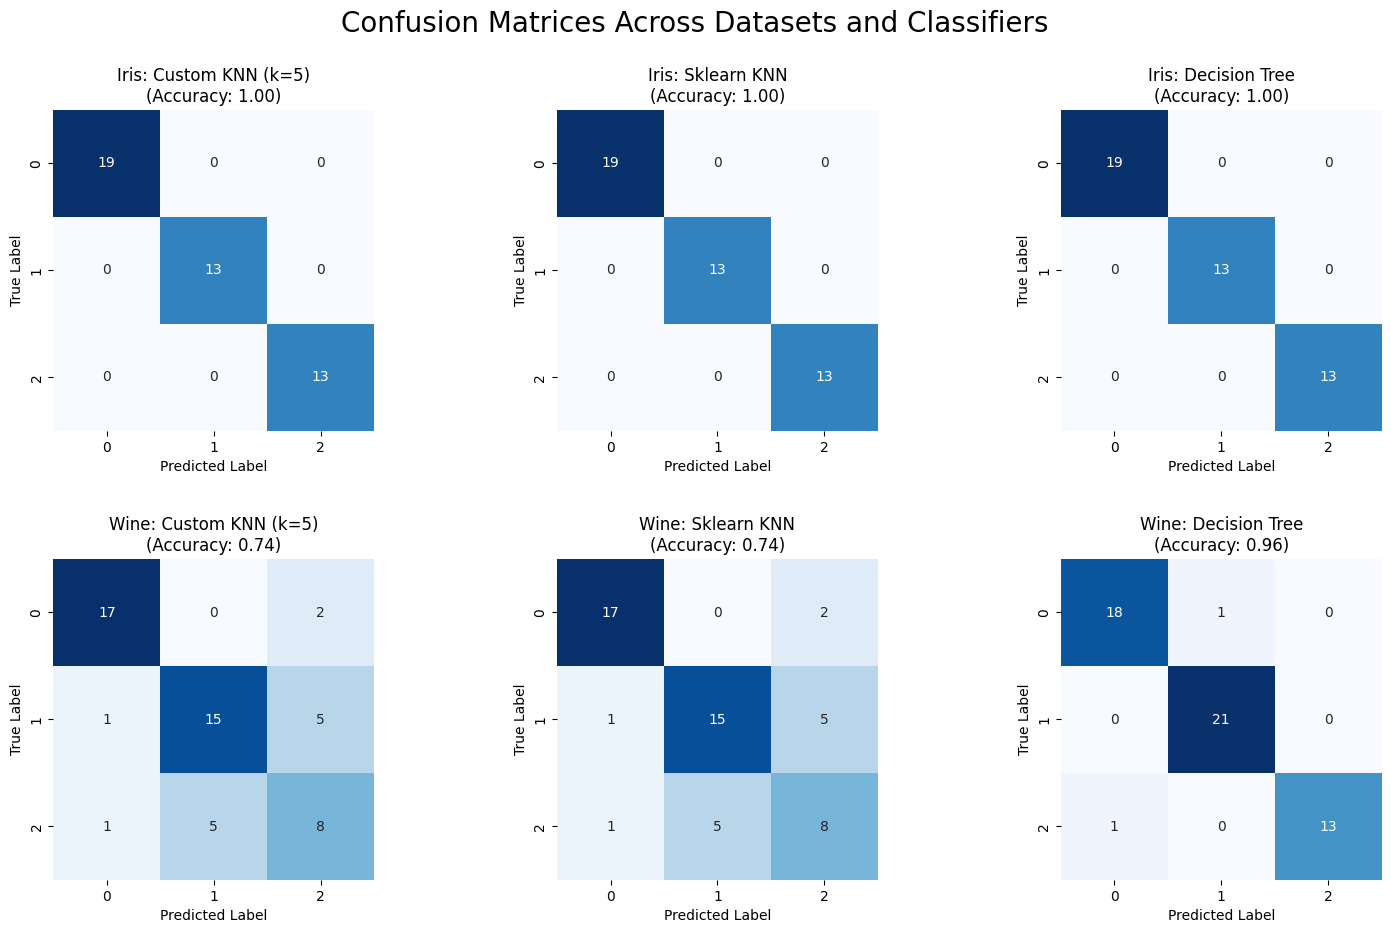

In [24]:
def visualize_results(final_result):
    # Set up the figure with subplots: 2 datasets (rows) x 3 classifiers (cols)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.subplots_adjust(hspace=0.4, wspace=0.3)

    datasets = ['Iris', 'Wine']
    # Map the internal keys to cleaner titles
    classifiers = ['Custom KNN (k=5)', 'Sklearn KNN', 'Decision Tree']

    for row, d_name in enumerate(datasets):
        for col, c_name in enumerate(classifiers):
            # Extract data from your dictionary
            cm = final_result[d_name][c_name]['Confusion Matrix']
            acc = final_result[d_name][c_name]['Accuracy']

            # Create heatmap on the specific subplot axis
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                        cbar=False, square=True)

            # Set titles and labels
            axes[row, col].set_title(f"{d_name}: {c_name}\n(Accuracy: {acc:.2f})")
            axes[row, col].set_xlabel("Predicted Label")
            axes[row, col].set_ylabel("True Label")

    plt.suptitle("Confusion Matrices Across Datasets and Classifiers", fontsize=20, y=0.98)
    plt.show()

# Run the visualization
visualize_results(final_results)

#### Decision Tree Structure
The Decision Tree visualization (for the Wine dataset) illustrates how the algorithm utilizes specific chemical features to partition the data space.



---

## 3. Discussion of the Results

### Analysis of Accuracy
The results show that all three classifiers achieved perfect accuracy on the **Iris** dataset, suggesting that the classes are well-separated in the 4D feature space. However, on the **Wine** dataset, the **Decision Tree** significantly outperformed both KNN implementations (96.3% vs 74.1%).

This discrepancy is primarily due to the nature of the features: the Wine dataset contains attributes with widely different scales. Because KNN relies on **Euclidean distance**, features with larger numerical ranges dominate the distance calculation. Decision Trees, being based on threshold splits rather than distances, are invariant to feature scaling, explaining their higher performance without prior data normalization.

### Runtime Performance Comparison
1.  **Training Time:** The **Custom KNN** implementation showed the lowest training time across all tests ($< 10^{-5}$ seconds). This is expected as KNN is a "Lazy Learner" that only stores the data in memory. In our fit method, we are simply performing an assignment (self.X_train = X). This is an $O(1)$ operation (constant time). The Scikit-learn KNN takes longer to train because it builds optimized search structures (like KD-Trees).
2.  **Prediction Time:** The **Decision Tree** was the fastest at prediction. Once the model is trained, prediction consists of simple boolean comparisons along the tree branches.
3.  **Implementation Differences:** There was negligible difference in accuracy between the Custom KNN and Scikit-Learn KNN, confirming the mathematical correctness of the custom implementation. However, the Scikit-learn implementation is generally more efficient for larger datasets due to its C-optimized backend and advanced indexing structures.

### Conclusion
While the custom KNN is effective for basic classification tasks, it is highly sensitive to feature scaling. In practical applications, the Decision Tree provides a more robust alternative for heterogeneous data, while Scikit-Learn's KNN is preferable for large-scale distance-based tasks due to its optimized prediction speed.